# Xây dựng Mô hình Phân loại và Dự báo Rủi ro Khách hàng Vay vốn

**Notebook 02/07 - Database Organization (Tổ chức database)**

---

**Mục tiêu:** Tổ chức dữ liệu raw vào PostgreSQL, tạo index, tổng hợp các bảng phụ về mức khách hàng và tạo bảng phẳng phục vụ các notebook sau.

**Input:** `data/raw/*.csv`, ERD và kết quả Data Understanding từ NB01

**Output:** Database raw, 6 bảng summary và bảng `application_flat` trong PostgreSQL

**Pipeline:** Data Understanding -> **Database Organization** -> Data Cleaning / EDA / Feature Engineering


## 1. Luồng làm việc của notebook

Notebook 02 thực hiện lần lượt các bước sau để tổ chức dữ liệu:

```
Tạo database -> Tạo bảng raw -> Import CSV
  -> Kiểm tra số dòng và kiểu dữ liệu -> Tạo index
  -> Tạo bảng summary -> Tạo application_flat
  -> Validation -> Bàn giao Notebook 03
```


## 2. Khởi tạo database và bảng

### 2.1. Tạo database

Database được tạo trực tiếp trong pgAdmin 4 bằng thao tác trên giao diện, không cần viết câu lệnh:

1. Mở **pgAdmin 4**, nhập master password nếu được hỏi.
2. Ở cây thư mục bên trái, mở **Servers** rồi chọn server **PostgreSQL** (nhập mật khẩu của user `postgres` nếu được hỏi).
3. Nhấp chuột phải vào **Databases**, chọn **Create**, rồi chọn **Database...**
4. Ở tab **General**, ô **Database** nhập `credit_risk_db`; ô **Owner** để `postgres`.
5. Nhấn **Save**.

Sau khi tạo xong, `credit_risk_db` xuất hiện trong danh sách **Databases**. Nếu database đã tồn tại thì bỏ qua bước này. Toàn bộ các bước sau của notebook đều phải chạy khi đang kết nối vào `credit_risk_db`.

`credit_risk_db` là nơi lưu toàn bộ bảng raw, bảng summary và bảng `application_flat` của dự án.


### 2.2. Tạo các bảng

In [ ]:
-- 01_create_tables.sql
-- Mục đích: tạo 8 bảng raw từ 8 file CSV chính của Home Credit.
-- Kiểu dữ liệu được khai báo gần với dữ liệu gốc để vừa dễ import vừa dễ giải thích.
-- Chạy file này sau khi đã kết nối vào database credit_risk_db.

-- Bảng application_train.csv
DROP TABLE IF EXISTS application_train CASCADE;
CREATE TABLE application_train (
    sk_id_curr BIGINT,
    target SMALLINT,
    name_contract_type TEXT,
    code_gender TEXT,
    flag_own_car TEXT,
    flag_own_realty TEXT,
    cnt_children NUMERIC,
    amt_income_total NUMERIC,
    amt_credit NUMERIC,
    amt_annuity NUMERIC,
    amt_goods_price NUMERIC,
    name_type_suite TEXT,
    name_income_type TEXT,
    name_education_type TEXT,
    name_family_status TEXT,
    name_housing_type TEXT,
    region_population_relative NUMERIC,
    days_birth NUMERIC,
    days_employed NUMERIC,
    days_registration NUMERIC,
    days_id_publish NUMERIC,
    own_car_age NUMERIC,
    flag_mobil SMALLINT,
    flag_emp_phone SMALLINT,
    flag_work_phone SMALLINT,
    flag_cont_mobile SMALLINT,
    flag_phone SMALLINT,
    flag_email SMALLINT,
    occupation_type TEXT,
    cnt_fam_members NUMERIC,
    region_rating_client NUMERIC,
    region_rating_client_w_city NUMERIC,
    weekday_appr_process_start TEXT,
    hour_appr_process_start NUMERIC,
    reg_region_not_live_region SMALLINT,
    reg_region_not_work_region SMALLINT,
    live_region_not_work_region SMALLINT,
    reg_city_not_live_city SMALLINT,
    reg_city_not_work_city SMALLINT,
    live_city_not_work_city SMALLINT,
    organization_type TEXT,
    ext_source_1 NUMERIC,
    ext_source_2 NUMERIC,
    ext_source_3 NUMERIC,
    apartments_avg NUMERIC,
    basementarea_avg NUMERIC,
    years_beginexpluatation_avg NUMERIC,
    years_build_avg NUMERIC,
    commonarea_avg NUMERIC,
    elevators_avg NUMERIC,
    entrances_avg NUMERIC,
    floorsmax_avg NUMERIC,
    floorsmin_avg NUMERIC,
    landarea_avg NUMERIC,
    livingapartments_avg NUMERIC,
    livingarea_avg NUMERIC,
    nonlivingapartments_avg NUMERIC,
    nonlivingarea_avg NUMERIC,
    apartments_mode NUMERIC,
    basementarea_mode NUMERIC,
    years_beginexpluatation_mode NUMERIC,
    years_build_mode NUMERIC,
    commonarea_mode NUMERIC,
    elevators_mode NUMERIC,
    entrances_mode NUMERIC,
    floorsmax_mode NUMERIC,
    floorsmin_mode NUMERIC,
    landarea_mode NUMERIC,
    livingapartments_mode NUMERIC,
    livingarea_mode NUMERIC,
    nonlivingapartments_mode NUMERIC,
    nonlivingarea_mode NUMERIC,
    apartments_medi NUMERIC,
    basementarea_medi NUMERIC,
    years_beginexpluatation_medi NUMERIC,
    years_build_medi NUMERIC,
    commonarea_medi NUMERIC,
    elevators_medi NUMERIC,
    entrances_medi NUMERIC,
    floorsmax_medi NUMERIC,
    floorsmin_medi NUMERIC,
    landarea_medi NUMERIC,
    livingapartments_medi NUMERIC,
    livingarea_medi NUMERIC,
    nonlivingapartments_medi NUMERIC,
    nonlivingarea_medi NUMERIC,
    fondkapremont_mode TEXT,
    housetype_mode TEXT,
    totalarea_mode NUMERIC,
    wallsmaterial_mode TEXT,
    emergencystate_mode TEXT,
    obs_30_cnt_social_circle NUMERIC,
    def_30_cnt_social_circle NUMERIC,
    obs_60_cnt_social_circle NUMERIC,
    def_60_cnt_social_circle NUMERIC,
    days_last_phone_change NUMERIC,
    flag_document_2 SMALLINT,
    flag_document_3 SMALLINT,
    flag_document_4 SMALLINT,
    flag_document_5 SMALLINT,
    flag_document_6 SMALLINT,
    flag_document_7 SMALLINT,
    flag_document_8 SMALLINT,
    flag_document_9 SMALLINT,
    flag_document_10 SMALLINT,
    flag_document_11 SMALLINT,
    flag_document_12 SMALLINT,
    flag_document_13 SMALLINT,
    flag_document_14 SMALLINT,
    flag_document_15 SMALLINT,
    flag_document_16 SMALLINT,
    flag_document_17 SMALLINT,
    flag_document_18 SMALLINT,
    flag_document_19 SMALLINT,
    flag_document_20 SMALLINT,
    flag_document_21 SMALLINT,
    amt_req_credit_bureau_hour NUMERIC,
    amt_req_credit_bureau_day NUMERIC,
    amt_req_credit_bureau_week NUMERIC,
    amt_req_credit_bureau_mon NUMERIC,
    amt_req_credit_bureau_qrt NUMERIC,
    amt_req_credit_bureau_year NUMERIC
);

-- Bảng raw từ file application_test.csv
DROP TABLE IF EXISTS application_test CASCADE;
CREATE TABLE application_test (
    sk_id_curr BIGINT,
    name_contract_type TEXT,
    code_gender TEXT,
    flag_own_car TEXT,
    flag_own_realty TEXT,
    cnt_children NUMERIC,
    amt_income_total NUMERIC,
    amt_credit NUMERIC,
    amt_annuity NUMERIC,
    amt_goods_price NUMERIC,
    name_type_suite TEXT,
    name_income_type TEXT,
    name_education_type TEXT,
    name_family_status TEXT,
    name_housing_type TEXT,
    region_population_relative NUMERIC,
    days_birth NUMERIC,
    days_employed NUMERIC,
    days_registration NUMERIC,
    days_id_publish NUMERIC,
    own_car_age NUMERIC,
    flag_mobil SMALLINT,
    flag_emp_phone SMALLINT,
    flag_work_phone SMALLINT,
    flag_cont_mobile SMALLINT,
    flag_phone SMALLINT,
    flag_email SMALLINT,
    occupation_type TEXT,
    cnt_fam_members NUMERIC,
    region_rating_client NUMERIC,
    region_rating_client_w_city NUMERIC,
    weekday_appr_process_start TEXT,
    hour_appr_process_start NUMERIC,
    reg_region_not_live_region SMALLINT,
    reg_region_not_work_region SMALLINT,
    live_region_not_work_region SMALLINT,
    reg_city_not_live_city SMALLINT,
    reg_city_not_work_city SMALLINT,
    live_city_not_work_city SMALLINT,
    organization_type TEXT,
    ext_source_1 NUMERIC,
    ext_source_2 NUMERIC,
    ext_source_3 NUMERIC,
    apartments_avg NUMERIC,
    basementarea_avg NUMERIC,
    years_beginexpluatation_avg NUMERIC,
    years_build_avg NUMERIC,
    commonarea_avg NUMERIC,
    elevators_avg NUMERIC,
    entrances_avg NUMERIC,
    floorsmax_avg NUMERIC,
    floorsmin_avg NUMERIC,
    landarea_avg NUMERIC,
    livingapartments_avg NUMERIC,
    livingarea_avg NUMERIC,
    nonlivingapartments_avg NUMERIC,
    nonlivingarea_avg NUMERIC,
    apartments_mode NUMERIC,
    basementarea_mode NUMERIC,
    years_beginexpluatation_mode NUMERIC,
    years_build_mode NUMERIC,
    commonarea_mode NUMERIC,
    elevators_mode NUMERIC,
    entrances_mode NUMERIC,
    floorsmax_mode NUMERIC,
    floorsmin_mode NUMERIC,
    landarea_mode NUMERIC,
    livingapartments_mode NUMERIC,
    livingarea_mode NUMERIC,
    nonlivingapartments_mode NUMERIC,
    nonlivingarea_mode NUMERIC,
    apartments_medi NUMERIC,
    basementarea_medi NUMERIC,
    years_beginexpluatation_medi NUMERIC,
    years_build_medi NUMERIC,
    commonarea_medi NUMERIC,
    elevators_medi NUMERIC,
    entrances_medi NUMERIC,
    floorsmax_medi NUMERIC,
    floorsmin_medi NUMERIC,
    landarea_medi NUMERIC,
    livingapartments_medi NUMERIC,
    livingarea_medi NUMERIC,
    nonlivingapartments_medi NUMERIC,
    nonlivingarea_medi NUMERIC,
    fondkapremont_mode TEXT,
    housetype_mode TEXT,
    totalarea_mode NUMERIC,
    wallsmaterial_mode TEXT,
    emergencystate_mode TEXT,
    obs_30_cnt_social_circle NUMERIC,
    def_30_cnt_social_circle NUMERIC,
    obs_60_cnt_social_circle NUMERIC,
    def_60_cnt_social_circle NUMERIC,
    days_last_phone_change NUMERIC,
    flag_document_2 SMALLINT,
    flag_document_3 SMALLINT,
    flag_document_4 SMALLINT,
    flag_document_5 SMALLINT,
    flag_document_6 SMALLINT,
    flag_document_7 SMALLINT,
    flag_document_8 SMALLINT,
    flag_document_9 SMALLINT,
    flag_document_10 SMALLINT,
    flag_document_11 SMALLINT,
    flag_document_12 SMALLINT,
    flag_document_13 SMALLINT,
    flag_document_14 SMALLINT,
    flag_document_15 SMALLINT,
    flag_document_16 SMALLINT,
    flag_document_17 SMALLINT,
    flag_document_18 SMALLINT,
    flag_document_19 SMALLINT,
    flag_document_20 SMALLINT,
    flag_document_21 SMALLINT,
    amt_req_credit_bureau_hour NUMERIC,
    amt_req_credit_bureau_day NUMERIC,
    amt_req_credit_bureau_week NUMERIC,
    amt_req_credit_bureau_mon NUMERIC,
    amt_req_credit_bureau_qrt NUMERIC,
    amt_req_credit_bureau_year NUMERIC
);

-- Bảng raw từ file bureau.csv
DROP TABLE IF EXISTS bureau CASCADE;
CREATE TABLE bureau (
    sk_id_curr BIGINT,
    sk_id_bureau BIGINT,
    credit_active TEXT,
    credit_currency TEXT,
    days_credit NUMERIC,
    credit_day_overdue INTEGER,
    days_credit_enddate NUMERIC,
    days_enddate_fact NUMERIC,
    amt_credit_max_overdue NUMERIC,
    cnt_credit_prolong NUMERIC,
    amt_credit_sum NUMERIC,
    amt_credit_sum_debt NUMERIC,
    amt_credit_sum_limit NUMERIC,
    amt_credit_sum_overdue NUMERIC,
    credit_type TEXT,
    days_credit_update NUMERIC,
    amt_annuity NUMERIC
);

-- Bảng raw từ file bureau_balance.csv
DROP TABLE IF EXISTS bureau_balance CASCADE;
CREATE TABLE bureau_balance (
    sk_id_bureau BIGINT,
    months_balance NUMERIC,
    status TEXT
);

-- Bảng raw từ file previous_application.csv
DROP TABLE IF EXISTS previous_application CASCADE;
CREATE TABLE previous_application (
    sk_id_prev BIGINT,
    sk_id_curr BIGINT,
    name_contract_type TEXT,
    amt_annuity NUMERIC,
    amt_application NUMERIC,
    amt_credit NUMERIC,
    amt_down_payment NUMERIC,
    amt_goods_price NUMERIC,
    weekday_appr_process_start TEXT,
    hour_appr_process_start NUMERIC,
    flag_last_appl_per_contract TEXT,
    nflag_last_appl_in_day SMALLINT,
    rate_down_payment NUMERIC,
    rate_interest_primary NUMERIC,
    rate_interest_privileged NUMERIC,
    name_cash_loan_purpose TEXT,
    name_contract_status TEXT,
    days_decision NUMERIC,
    name_payment_type TEXT,
    code_reject_reason TEXT,
    name_type_suite TEXT,
    name_client_type TEXT,
    name_goods_category TEXT,
    name_portfolio TEXT,
    name_product_type TEXT,
    channel_type TEXT,
    sellerplace_area NUMERIC,
    name_seller_industry TEXT,
    cnt_payment NUMERIC,
    name_yield_group TEXT,
    product_combination TEXT,
    days_first_drawing NUMERIC,
    days_first_due NUMERIC,
    days_last_due_1st_version NUMERIC,
    days_last_due NUMERIC,
    days_termination NUMERIC,
    nflag_insured_on_approval NUMERIC
);

-- Bảng raw từ file installments_payments.csv
DROP TABLE IF EXISTS installments_payments CASCADE;
CREATE TABLE installments_payments (
    sk_id_prev BIGINT,
    sk_id_curr BIGINT,
    num_instalment_version NUMERIC,
    num_instalment_number NUMERIC,
    days_instalment NUMERIC,
    days_entry_payment NUMERIC,
    amt_instalment NUMERIC,
    amt_payment NUMERIC
);

-- Bảng raw từ file POS_CASH_balance.csv
DROP TABLE IF EXISTS pos_cash_balance CASCADE;
CREATE TABLE pos_cash_balance (
    sk_id_prev BIGINT,
    sk_id_curr BIGINT,
    months_balance NUMERIC,
    cnt_instalment NUMERIC,
    cnt_instalment_future NUMERIC,
    name_contract_status TEXT,
    sk_dpd NUMERIC,
    sk_dpd_def NUMERIC
);

-- Bảng raw từ file credit_card_balance.csv
DROP TABLE IF EXISTS credit_card_balance CASCADE;
CREATE TABLE credit_card_balance (
    sk_id_prev BIGINT,
    sk_id_curr BIGINT,
    months_balance NUMERIC,
    amt_balance NUMERIC,
    amt_credit_limit_actual NUMERIC,
    amt_drawings_atm_current NUMERIC,
    amt_drawings_current NUMERIC,
    amt_drawings_other_current NUMERIC,
    amt_drawings_pos_current NUMERIC,
    amt_inst_min_regularity NUMERIC,
    amt_payment_current NUMERIC,
    amt_payment_total_current NUMERIC,
    amt_receivable_principal NUMERIC,
    amt_recivable NUMERIC,
    amt_total_receivable NUMERIC,
    cnt_drawings_atm_current NUMERIC,
    cnt_drawings_current NUMERIC,
    cnt_drawings_other_current NUMERIC,
    cnt_drawings_pos_current NUMERIC,
    cnt_instalment_mature_cum NUMERIC,
    name_contract_status TEXT,
    sk_dpd NUMERIC,
    sk_dpd_def NUMERIC
);

**Nhận xét:** Các khóa `SK_ID_CURR`, `SK_ID_PREV`, `SK_ID_BUREAU` được khai báo `BIGINT`; `TARGET` và các cờ nhị phân khai báo `SMALLINT`; các biến số tiền, số ngày, tỷ lệ và số đếm khai báo `NUMERIC`; biến phân loại giữ `TEXT`. Cách này giúp bảng raw có kiểu dữ liệu rõ hơn nhưng vẫn chưa làm cleaning sâu.


## 3. Import dữ liệu raw vào PostgreSQL

### 3.1. Import dữ liệu bằng lệnh COPY

Đoạn code bên dưới dùng lệnh `COPY` trong pgAdmin Query Tool để nạp 8 file CSV vào các bảng raw. Đường dẫn CSV là đường dẫn tuyệt đối trên máy đang chạy PostgreSQL, vì vậy thành viên khác cần sửa lại đường dẫn theo máy của mình trước khi chạy.

In [ ]:
-- 02_import_data.sql
-- Muc dich: import 8 file CSV raw vao PostgreSQL bang pgAdmin Query Tool.
-- Luu y: COPY doc file tu may PostgreSQL server, nen duong dan ben duoi can ton tai voi server.
-- Neu may thanh vien dat project o thu muc khac, hay sua lai duong dan truoc khi chay.

TRUNCATE TABLE
    application_train,
    application_test,
    bureau,
    bureau_balance,
    previous_application,
    installments_payments,
    pos_cash_balance,
    credit_card_balance;

COPY application_train
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/application_train.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY application_test
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/application_test.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY bureau
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/bureau.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY bureau_balance
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/bureau_balance.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY previous_application
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/previous_application.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY installments_payments
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/installments_payments.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY pos_cash_balance
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/POS_CASH_balance.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

COPY credit_card_balance
FROM 'D:/FPT Polytechnic/2026/HK Summer 2026/Block2/Du-an-01/credit-risk-classifier/data/raw/credit_card_balance.csv'
WITH (FORMAT csv, HEADER true, DELIMITER ',', NULL '', QUOTE '"');

**Nhận xét:** `COPY` chạy trực tiếp trong pgAdmin Query Tool nên thống nhất với các bước tạo database và bảng raw ở Mục 2. Điểm cần chú ý là PostgreSQL server phải có quyền đọc các file CSV trong đường dẫn đã khai báo.

### 3.2. Kiểm tra số dòng sau import

Sau khi import, cần đối chiếu số dòng từng bảng trong PostgreSQL với số dòng đã ghi nhận ở NB01.


In [ ]:
-- 03_check_import_counts.sql
-- Muc dich: kiem tra so dong sau import co khop voi ket qua da ghi nhan o NB01 hay khong.

SELECT 'application_train' AS table_name, 307511::BIGINT AS expected_rows, COUNT(*)::BIGINT AS actual_rows,
       CASE WHEN COUNT(*) = 307511 THEN 'OK' ELSE 'CAN_KIEM_TRA' END AS result
FROM application_train
UNION ALL
SELECT 'application_test', 48744::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 48744 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM application_test
UNION ALL
SELECT 'bureau', 1716428::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 1716428 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM bureau
UNION ALL
SELECT 'bureau_balance', 27299925::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 27299925 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM bureau_balance
UNION ALL
SELECT 'previous_application', 1670214::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 1670214 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM previous_application
UNION ALL
SELECT 'installments_payments', 13605401::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 13605401 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM installments_payments
UNION ALL
SELECT 'pos_cash_balance', 10001358::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 10001358 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM pos_cash_balance
UNION ALL
SELECT 'credit_card_balance', 3840312::BIGINT, COUNT(*)::BIGINT,
       CASE WHEN COUNT(*) = 3840312 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM credit_card_balance;

**Nhận xét:** Nếu tất cả bảng trả về `OK`, dữ liệu raw đã được nạp đủ số dòng vào PostgreSQL. Bước tiếp theo là kiểm tra dữ liệu có nằm đúng cột và đúng kiểu hay không.


### 3.3. Kiểm tra kiểu dữ liệu sau import


Số dòng đủ chưa đủ để kết luận import thành công. Lệnh `COPY` ghép dữ liệu **theo vị trí cột**, không theo tên cột, nên nếu thứ tự cột trong `CREATE TABLE` lệch so với file CSV thì dữ liệu vẫn được nạp nhưng vào sai cột và không có cảnh báo nào.

Đoạn code bên dưới đối chiếu số cột và số cột kiểu chữ của từng bảng trong PostgreSQL với thiết kế ở `01_create_tables.sql`.


In [ ]:
-- 04_check_column_types.sql
-- Muc dich: kiem tra kieu du lieu sau import co dung nhu thiet ke trong 01_create_tables.sql hay khong.
-- COPY ghep du lieu THEO VI TRI COT chu khong theo ten cot, nen neu so cot lech thi
-- du lieu co the vao nham cot ma van import thanh cong, khong bao loi.
-- Cot kieu chu cung phai dung so luong: mot cot dang le la so ma khai thanh TEXT
-- se lam SUM/AVG bao loi va MAX so sanh theo bang chu cai (vi du '9' > '2792').

SELECT
    mong_doi.table_name,
    mong_doi.so_cot_mong_doi,
    COUNT(cols.column_name) AS so_cot_thuc_te,
    mong_doi.so_cot_chu_mong_doi,
    SUM(CASE WHEN cols.data_type = 'text' THEN 1 ELSE 0 END) AS so_cot_chu_thuc_te,
    CASE
        WHEN COUNT(cols.column_name) = mong_doi.so_cot_mong_doi
         AND SUM(CASE WHEN cols.data_type = 'text' THEN 1 ELSE 0 END) = mong_doi.so_cot_chu_mong_doi
        THEN 'OK'
        ELSE 'CAN_KIEM_TRA'
    END AS result,
    STRING_AGG(DISTINCT cols.data_type, ', ' ORDER BY cols.data_type) AS cac_kieu_du_lieu
FROM (VALUES
    ('application_train',     122, 16),
    ('application_test',      121, 16),
    ('bureau',                 17,  3),
    ('bureau_balance',          3,  1),
    ('previous_application',   37, 16),
    ('installments_payments',   8,  0),
    ('pos_cash_balance',        8,  1),
    ('credit_card_balance',    23,  1)
) AS mong_doi (table_name, so_cot_mong_doi, so_cot_chu_mong_doi)
LEFT JOIN information_schema.columns AS cols
       ON cols.table_schema = 'public'
      AND cols.table_name = mong_doi.table_name
GROUP BY mong_doi.table_name, mong_doi.so_cot_mong_doi, mong_doi.so_cot_chu_mong_doi
ORDER BY mong_doi.table_name;

**Nhận xét:** Tất cả bảng trả về `OK` — tổng cộng 339 cột, khớp cả về số lượng lẫn số cột kiểu chữ so với thiết kế. Quá trình kiểm tra đã phát hiện và sửa ba lỗi kiểu dữ liệu: hai cột `FLAG_OWN_CAR` / `FLAG_OWN_REALTY` chứa `'Y'`/`'N'` nhưng khai `SMALLINT`, cột `NFLAG_INSURED_ON_APPROVAL` chứa `'0.0'` nhưng khai `SMALLINT`, và cột `CREDIT_DAY_OVERDUE` chứa số nguyên nhưng khai `TEXT`.

Lỗi thứ ba nguy hiểm nhất vì không làm import thất bại: nếu để kiểu `TEXT`, hàm `MAX()` sẽ so sánh theo bảng chữ cái nên `'9'` được coi là lớn hơn `'2792'`, khiến số ngày trễ hạn lớn nhất của khách hàng bị ghi nhận sai ở bước tạo bảng summary.


## 4. Tối ưu database

Đoạn code bên dưới tạo index trên các khóa nối của bảng trung tâm và các bảng phụ.

In [ ]:
-- 05_create_indexes.sql
-- Muc dich: tao index tren cac khoa noi truoc khi tao bang summary va bang phang.
-- Index giup PostgreSQL tim nhanh cac dong theo khoa thay vi quet ca bang.
-- Chay file nay sau khi da import du lieu raw va kiem tra so dong.

-- Khoa chinh cua bang trung tam, dung khi join voi cac bang summary o Muc 6.
DROP INDEX IF EXISTS idx_application_train_curr;
CREATE INDEX idx_application_train_curr ON application_train (sk_id_curr);

DROP INDEX IF EXISTS idx_application_test_curr;
CREATE INDEX idx_application_test_curr ON application_test (sk_id_curr);

-- Cac bang phu noi ve khach hang bang sk_id_curr.
DROP INDEX IF EXISTS idx_bureau_curr;
CREATE INDEX idx_bureau_curr ON bureau (sk_id_curr);

DROP INDEX IF EXISTS idx_previous_application_curr;
CREATE INDEX idx_previous_application_curr ON previous_application (sk_id_curr);

DROP INDEX IF EXISTS idx_installments_payments_curr;
CREATE INDEX idx_installments_payments_curr ON installments_payments (sk_id_curr);

DROP INDEX IF EXISTS idx_pos_cash_balance_curr;
CREATE INDEX idx_pos_cash_balance_curr ON pos_cash_balance (sk_id_curr);

DROP INDEX IF EXISTS idx_credit_card_balance_curr;
CREATE INDEX idx_credit_card_balance_curr ON credit_card_balance (sk_id_curr);

-- bureau_balance khong co sk_id_curr, phai noi vong qua bureau bang sk_id_bureau.
-- Hai index duoi day phuc vu dung phep noi do.
DROP INDEX IF EXISTS idx_bureau_bureau_id;
CREATE INDEX idx_bureau_bureau_id ON bureau (sk_id_bureau);

DROP INDEX IF EXISTS idx_bureau_balance_bureau_id;
CREATE INDEX idx_bureau_balance_bureau_id ON bureau_balance (sk_id_bureau);

**Nhận xét:** Index giúp PostgreSQL tìm nhanh các dòng theo khóa thay vì quét toàn bộ bảng. Trong notebook này index có tác dụng rõ nhất ở hai chỗ: bước gom nhóm theo `sk_id_curr` khi tạo các bảng summary ở Mục 5, và phép join bảng trung tâm với các bảng summary ở Mục 6.


## 5. Tạo bảng summary

### 5.1. Vì sao phải tạo bảng summary

Mỗi khách hàng có nhiều dòng ở các bảng phụ. Ví dụ 1 khách hàng có 11 khoản vay trong `bureau`, trong khi ở `application_train` chỉ có 1 dòng. Nếu join thẳng, khách này bị nhân từ 1 dòng thành 11 dòng, làm sai thống kê và sai kết quả huấn luyện mô hình.

Vì vậy mỗi bảng phụ phải được gom về một dòng cho mỗi khách hàng trước khi join. Đó là lý do cần các bảng summary ở bước tiếp theo.

### 5.2. Tạo 6 bảng summary

`GROUP BY sk_id_curr` dồn mọi dòng của cùng một khách vào một nhóm, và mỗi nhóm chỉ được xuất ra một dòng. Vì vậy phải chọn giữ lại con số nào từ nhóm đó: `COUNT` đếm số dòng, `SUM` cộng toàn bộ, `AVG` lấy trung bình, `MAX` và `MIN` lấy giá trị lớn nhất và nhỏ nhất.

Riêng `MAX` quan trọng nhất với bài toán rủi ro. Hai khách cùng có số ngày quá hạn trung bình là 5 ngày, nhưng một người trễ đều 5 ngày mỗi kỳ, còn người kia đúng hạn suốt rồi trễ 120 ngày một lần — chỉ `MAX` phân biệt được hai trường hợp này.

Bảng cột của từng bảng summary nằm ngay trước mỗi đoạn code bên dưới.


#### 5.2.1. Gom `bureau_balance` qua hai tầng

`bureau_balance` chỉ có `sk_id_bureau`, còn `application_flat` cần một dòng cho mỗi khách hàng theo `sk_id_curr`. Vì vậy không thể gom trực tiếp bảng này về khách hàng.

```text
bureau_balance (nhiều tháng / khoản vay)
  -> GROUP BY sk_id_bureau: bureau_balance_summary (1 dòng / khoản vay)
  -> LEFT JOIN bureau: lấy sk_id_curr cho từng khoản vay
  -> GROUP BY sk_id_curr: bureau_summary (1 dòng / khách hàng)
```

Ở tầng đầu, `COUNT` đếm số tháng lịch sử; `FILTER` đếm riêng tháng quá hạn (`STATUS` từ `1` đến `5`), tháng đã đóng (`C`) và tháng chưa có trạng thái (`X`); `MAX` lấy mức quá hạn nặng nhất. Sau khi `LEFT JOIN` với `bureau`, mỗi khoản vay vẫn chỉ có một dòng vì `bureau_balance_summary` đã được gom theo `sk_id_bureau`; do đó lần `GROUP BY sk_id_curr` sau đó không làm nổ số dòng.

Đoạn code bên dưới thực hiện cả hai tầng này, rồi tạo các cột `bureau_balance_*` trong `bureau_summary`.

Đoạn code bên dưới gom `bureau_balance` theo từng khoản vay (`sk_id_bureau`).

| Cột tạo ra | Hàm | Nghĩa |
|---|---|---|
| `bureau_balance_month_count` | `COUNT(*)` | Tổng số tháng lịch sử của khoản vay |
| `bureau_balance_dpd_month_count` | `COUNT ... FILTER` | Số tháng có trạng thái quá hạn từ `1` đến `5` |
| `bureau_balance_max_dpd_status` | `MAX(...)` | Mức quá hạn nặng nhất của khoản vay |
| `bureau_balance_closed_month_count` | `COUNT ... FILTER` | Số tháng trạng thái đã đóng `C` |
| `bureau_balance_unknown_month_count` | `COUNT ... FILTER` | Số tháng chưa có trạng thái `X` |

Chỉ các trạng thái số từ `1` đến `5` mới được dùng để xác định quá hạn; `C` và `X` được đếm riêng để không bị hiểu nhầm là mức quá hạn.


In [ ]:
-- 1. bureau_balance: 1 dong / sk_id_bureau
-- STATUS '0' khong qua han; '1' den '5' la cac muc qua han; 'C' da dong; 'X' chua co trang thai.
DROP TABLE IF EXISTS bureau_balance_summary CASCADE;

CREATE TABLE bureau_balance_summary AS
SELECT
    sk_id_bureau,
    COUNT(*) AS bureau_balance_month_count,
    COUNT(*) FILTER (WHERE status IN ('1', '2', '3', '4', '5')) AS bureau_balance_dpd_month_count,
    MAX(CASE WHEN status IN ('1', '2', '3', '4', '5') THEN status::SMALLINT END) AS bureau_balance_max_dpd_status,
    COUNT(*) FILTER (WHERE status = 'C') AS bureau_balance_closed_month_count,
    COUNT(*) FILTER (WHERE status = 'X') AS bureau_balance_unknown_month_count
FROM bureau_balance
GROUP BY sk_id_bureau;

CREATE UNIQUE INDEX idx_bureau_balance_summary_bureau ON bureau_balance_summary (sk_id_bureau);

#### 5.2.2. Tạo `bureau_summary`

Đoạn code bên dưới nối `bureau_balance_summary` vào `bureau` theo `sk_id_bureau`, sau đó gom các khoản vay về từng khách hàng theo `sk_id_curr`.

| Cột tạo ra | Hàm | Nghĩa |
|---|---|---|
| `bureau_count` | `COUNT(*)` | Số khoản vay tại tổ chức tín dụng khác |
| `bureau_sum_credit` | `SUM(amt_credit_sum)` | Tổng số tiền đã vay |
| `bureau_sum_debt` | `SUM(amt_credit_sum_debt)` | Tổng dư nợ còn lại |
| `bureau_max_overdue` | `MAX(credit_day_overdue)` | Số ngày trễ hạn nhiều nhất |
| `bureau_balance_delinquent_loan_count` | `COUNT ... FILTER` | Số khoản từng có tháng quá hạn |
| `bureau_balance_dpd_month_count` | `SUM(...)` | Tổng số tháng quá hạn trên mọi khoản |
| `bureau_balance_max_dpd_status` | `MAX(...)` | Mức quá hạn nặng nhất trong lịch sử khách |


In [ ]:
-- 2. bureau: noi summary theo khoan vay, sau do gom ve 1 dong / sk_id_curr
DROP TABLE IF EXISTS bureau_summary CASCADE;

CREATE TABLE bureau_summary AS
SELECT
    b.sk_id_curr,
    COUNT(*)                 AS bureau_count,
    SUM(b.amt_credit_sum)      AS bureau_sum_credit,
    SUM(b.amt_credit_sum_debt) AS bureau_sum_debt,
    MAX(b.credit_day_overdue)  AS bureau_max_overdue,
    AVG(b.days_credit)         AS bureau_avg_days_credit,
    MAX(b.days_credit)         AS bureau_latest_days_credit,
    COUNT(*) FILTER (WHERE COALESCE(bb.bureau_balance_dpd_month_count, 0) > 0) AS bureau_balance_delinquent_loan_count,
    SUM(COALESCE(bb.bureau_balance_dpd_month_count, 0)) AS bureau_balance_dpd_month_count,
    MAX(COALESCE(bb.bureau_balance_max_dpd_status, 0)) AS bureau_balance_max_dpd_status,
    SUM(COALESCE(bb.bureau_balance_closed_month_count, 0)) AS bureau_balance_closed_month_count,
    SUM(COALESCE(bb.bureau_balance_unknown_month_count, 0)) AS bureau_balance_unknown_month_count,
    SUM(COALESCE(bb.bureau_balance_month_count, 0)) AS bureau_balance_month_count
FROM bureau b
LEFT JOIN bureau_balance_summary bb ON bb.sk_id_bureau = b.sk_id_bureau
GROUP BY b.sk_id_curr;

CREATE UNIQUE INDEX idx_bureau_summary_curr ON bureau_summary (sk_id_curr);

#### 5.2.3. Tạo `previous_application_summary`

Đoạn code bên dưới gom bảng `previous_application` — các hồ sơ vay trước đây tại Home Credit.

| Cột tạo ra | Hàm | Nghĩa |
|---|---|---|
| `previous_count` | `COUNT(*)` | Khách từng nộp bao nhiêu hồ sơ vay |
| `previous_sum_credit` | `SUM(amt_credit)` | Tổng số tiền từng được duyệt |
| `previous_avg_credit` | `AVG(amt_credit)` | Quy mô mỗi khoản vay điển hình |
| `previous_avg_days_decision` | `AVG(days_decision)` | Các hồ sơ cũ cách đây trung bình bao lâu |
| `previous_latest_decision` | `MAX(days_decision)` | Hồ sơ gần nhất cách đây bao lâu |

Đặt `SUM` cạnh `AVG` để phân biệt khách vay một khoản lớn với khách vay nhiều khoản nhỏ, dù tổng tiền có thể bằng nhau.


In [ ]:
-- 3. previous_application
DROP TABLE IF EXISTS previous_application_summary CASCADE;

CREATE TABLE previous_application_summary AS
SELECT
    sk_id_curr,
    COUNT(*)           AS previous_count,
    SUM(amt_credit)    AS previous_sum_credit,
    AVG(amt_credit)    AS previous_avg_credit,
    AVG(days_decision) AS previous_avg_days_decision,
    MAX(days_decision) AS previous_latest_decision
FROM previous_application
GROUP BY sk_id_curr;

CREATE UNIQUE INDEX idx_previous_application_summary_curr ON previous_application_summary (sk_id_curr);

#### 5.2.4. Tạo `installments_payments_summary`

Đoạn code bên dưới gom bảng `installments_payments` — lịch sử trả góp từng kỳ.

| Cột tạo ra | Hàm | Nghĩa |
|---|---|---|
| `installments_count` | `COUNT(*)` | Khách đã trả bao nhiêu kỳ |
| `installments_sum_due` | `SUM(amt_instalment)` | Tổng số tiền phải trả |
| `installments_sum_paid` | `SUM(amt_payment)` | Tổng số tiền đã trả thực tế |
| `installments_avg_late` | `AVG(days_entry_payment - days_instalment)` | Trung bình trả trễ bao nhiêu ngày |
| `installments_max_late` | `MAX(days_entry_payment - days_instalment)` | Lần trả trễ nhiều nhất |

`days_instalment` là hạn phải trả, `days_entry_payment` là ngày trả thực tế, nên hiệu hai cột mang dấu dương là trả trễ và mang dấu âm là trả sớm. Đặt `installments_sum_paid` cạnh `installments_sum_due` để thấy khách trả đủ hay còn thiếu.


In [ ]:
-- 4. installments_payments
DROP TABLE IF EXISTS installments_payments_summary CASCADE;

CREATE TABLE installments_payments_summary AS
SELECT
    sk_id_curr,
    COUNT(*)                                  AS installments_count,
    SUM(amt_instalment)                       AS installments_sum_due,
    SUM(amt_payment)                          AS installments_sum_paid,
    AVG(days_entry_payment - days_instalment) AS installments_avg_late,
    MAX(days_entry_payment - days_instalment) AS installments_max_late
FROM installments_payments
GROUP BY sk_id_curr;

CREATE UNIQUE INDEX idx_installments_payments_summary_curr ON installments_payments_summary (sk_id_curr);

#### 5.2.5. Tạo `pos_cash_balance_summary`

Đoạn code bên dưới gom bảng `pos_cash_balance` — số dư hàng tháng của khoản vay trả góp và vay tiền mặt.

| Cột tạo ra | Hàm | Nghĩa |
|---|---|---|
| `pos_cash_count` | `COUNT(*)` | Có bao nhiêu tháng dữ liệu |
| `pos_cash_avg_dpd` | `AVG(sk_dpd)` | Số ngày quá hạn trung bình mỗi tháng |
| `pos_cash_max_dpd` | `MAX(sk_dpd)` | Số ngày quá hạn tối đa từng chạm tới |
| `pos_cash_oldest_month` | `MIN(months_balance)` | Tháng cũ nhất có dữ liệu |
| `pos_cash_latest_month` | `MAX(months_balance)` | Tháng gần nhất có dữ liệu |

`sk_dpd` là số ngày quá hạn. Cặp `MIN` và `MAX` của `months_balance` cho biết dữ liệu trải dài từ tháng nào đến tháng nào.


In [ ]:
-- 5. pos_cash_balance
DROP TABLE IF EXISTS pos_cash_balance_summary CASCADE;

CREATE TABLE pos_cash_balance_summary AS
SELECT
    sk_id_curr,
    COUNT(*)            AS pos_cash_count,
    AVG(sk_dpd)         AS pos_cash_avg_dpd,
    MAX(sk_dpd)         AS pos_cash_max_dpd,
    MIN(months_balance) AS pos_cash_oldest_month,
    MAX(months_balance) AS pos_cash_latest_month
FROM pos_cash_balance
GROUP BY sk_id_curr;

CREATE UNIQUE INDEX idx_pos_cash_balance_summary_curr ON pos_cash_balance_summary (sk_id_curr);

#### 5.2.6. Tạo `credit_card_balance_summary`

Đoạn code bên dưới gom bảng `credit_card_balance` — số dư hàng tháng của thẻ tín dụng.

| Cột tạo ra | Hàm | Nghĩa |
|---|---|---|
| `credit_card_count` | `COUNT(*)` | Có bao nhiêu tháng dữ liệu |
| `credit_card_avg_balance` | `AVG(amt_balance)` | Dư nợ thẻ trung bình |
| `credit_card_max_balance` | `MAX(amt_balance)` | Dư nợ thẻ cao nhất từng chạm tới |
| `credit_card_avg_limit` | `AVG(amt_credit_limit_actual)` | Hạn mức thẻ trung bình được cấp |
| `credit_card_max_dpd` | `MAX(sk_dpd)` | Số ngày quá hạn tối đa |

Đặt `credit_card_max_balance` cạnh `credit_card_avg_limit` để thấy khách đã dùng tới bao nhiêu phần hạn mức được cấp.


In [ ]:
-- 6. credit_card_balance
DROP TABLE IF EXISTS credit_card_balance_summary CASCADE;

CREATE TABLE credit_card_balance_summary AS
SELECT
    sk_id_curr,
    COUNT(*)                     AS credit_card_count,
    AVG(amt_balance)             AS credit_card_avg_balance,
    MAX(amt_balance)             AS credit_card_max_balance,
    AVG(amt_credit_limit_actual) AS credit_card_avg_limit,
    MAX(sk_dpd)                  AS credit_card_max_dpd
FROM credit_card_balance
GROUP BY sk_id_curr;

CREATE UNIQUE INDEX idx_credit_card_balance_summary_curr ON credit_card_balance_summary (sk_id_curr);

**Nhận xét:** Sáu bảng summary đã được tạo. `bureau_balance_summary` có một dòng cho mỗi khoản tín dụng (`sk_id_bureau`), sau đó được nối vào `bureau` trước khi `bureau_summary` gom tiếp về một dòng cho mỗi khách hàng (`sk_id_curr`). Năm bảng summary còn lại đều gom thẳng về mức khách hàng.


### 5.3. Kiểm tra mỗi khách hàng chỉ còn một dòng

Bảng summary chỉ dùng được nếu thật sự đạt mức một dòng cho mỗi khách hàng. Đoạn code bên dưới đối chiếu tổng số dòng với số khách hàng riêng biệt của từng bảng — hai con số bằng nhau nghĩa là không còn khách nào bị lặp.


In [ ]:
-- 07_check_summary_grain.sql
-- Muc dich: kiem chung moi bang summary chi con dung 1 dong theo khoa gom nhom.
-- bureau_balance_summary dung 1 dong / SK_ID_BUREAU; cac bang con lai dung 1 dong / SK_ID_CURR.

SELECT 'bureau_balance_summary' AS table_name,
       COUNT(*)::BIGINT AS total_rows,
       COUNT(DISTINCT sk_id_bureau)::BIGINT AS distinct_keys,
       CASE WHEN COUNT(*) = COUNT(DISTINCT sk_id_bureau) THEN 'OK' ELSE 'CAN_KIEM_TRA' END AS result
FROM bureau_balance_summary
UNION ALL
SELECT 'bureau_summary', COUNT(*)::BIGINT, COUNT(DISTINCT sk_id_curr)::BIGINT,
       CASE WHEN COUNT(*) = COUNT(DISTINCT sk_id_curr) THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM bureau_summary
UNION ALL
SELECT 'previous_application_summary', COUNT(*)::BIGINT, COUNT(DISTINCT sk_id_curr)::BIGINT,
       CASE WHEN COUNT(*) = COUNT(DISTINCT sk_id_curr) THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM previous_application_summary
UNION ALL
SELECT 'installments_payments_summary', COUNT(*)::BIGINT, COUNT(DISTINCT sk_id_curr)::BIGINT,
       CASE WHEN COUNT(*) = COUNT(DISTINCT sk_id_curr) THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM installments_payments_summary
UNION ALL
SELECT 'pos_cash_balance_summary', COUNT(*)::BIGINT, COUNT(DISTINCT sk_id_curr)::BIGINT,
       CASE WHEN COUNT(*) = COUNT(DISTINCT sk_id_curr) THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM pos_cash_balance_summary
UNION ALL
SELECT 'credit_card_balance_summary', COUNT(*)::BIGINT, COUNT(DISTINCT sk_id_curr)::BIGINT,
       CASE WHEN COUNT(*) = COUNT(DISTINCT sk_id_curr) THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM credit_card_balance_summary;

**Nhận xét:** Cả năm bảng trả về `OK`, tổng số dòng bằng đúng số khách hàng riêng biệt. Các bảng summary đã đạt mức dữ liệu một dòng cho mỗi khách hàng nên join vào `application_train` ở Mục 6 sẽ không làm nở số dòng.


## 6. Join tạo bảng application_flat

### 6.1. Xác định các bảng summary cần join

```
application_train  (307.511 dòng, 122 cột)
        │  sk_id_curr
        ├── LEFT JOIN  bureau_summary         +6 cột
        ├── LEFT JOIN  previous_application_summary +5 cột
        ├── LEFT JOIN  installments_payments_summary +5 cột
        ├── LEFT JOIN  pos_cash_balance_summary +5 cột
        └── LEFT JOIN  credit_card_balance_summary +5 cột
                    ↓
        application_flat  (307.511 dòng, 154 cột)
```

Năm bảng summary ở mức khách hàng đều có một dòng cho mỗi `sk_id_curr`, nên khi join vào `application_train` chúng là quan hệ 1-1 và không làm thay đổi số dòng. `bureau_balance_summary` đã được gom ở mức khoản vay bên trong bước tạo `bureau_summary`, nên không được join trực tiếp vào `application_flat`.

Dùng `LEFT JOIN` để không loại mất những khách chưa từng vay ở đâu — các cột summary của họ nhận `NULL` và sẽ được xử lý ở NB03.


### 6.2. Tạo bảng application_flat trong PostgreSQL

Đoạn code bên dưới tạo bảng `application_flat` từ `application_train` và 5 bảng summary ở mức khách hàng.


In [ ]:
-- 08_create_application_flat.sql
-- Muc dich: gop application_train voi 5 bang summary thanh bang phang 1 khach = 1 dong.
-- Giai thich chi tiet: xem Muc 6 trong notebook 02.

DROP TABLE IF EXISTS application_flat CASCADE;

CREATE TABLE application_flat AS
SELECT
    a.*,
    b.bureau_count,
    b.bureau_sum_credit,
    b.bureau_sum_debt,
    b.bureau_max_overdue,
    b.bureau_avg_days_credit,
    b.bureau_latest_days_credit,
    b.bureau_balance_delinquent_loan_count,
    b.bureau_balance_dpd_month_count,
    b.bureau_balance_max_dpd_status,
    b.bureau_balance_closed_month_count,
    b.bureau_balance_unknown_month_count,
    b.bureau_balance_month_count,

    p.previous_count,
    p.previous_sum_credit,
    p.previous_avg_credit,
    p.previous_avg_days_decision,
    p.previous_latest_decision,

    i.installments_count,
    i.installments_sum_due,
    i.installments_sum_paid,
    i.installments_avg_late,
    i.installments_max_late,

    pc.pos_cash_count,
    pc.pos_cash_avg_dpd,
    pc.pos_cash_max_dpd,
    pc.pos_cash_oldest_month,
    pc.pos_cash_latest_month,

    cc.credit_card_count,
    cc.credit_card_avg_balance,
    cc.credit_card_max_balance,
    cc.credit_card_avg_limit,
    cc.credit_card_max_dpd
FROM application_train a
LEFT JOIN bureau_summary         b   ON b.sk_id_curr = a.sk_id_curr
LEFT JOIN previous_application_summary   p   ON p.sk_id_curr = a.sk_id_curr
LEFT JOIN installments_payments_summary   i   ON i.sk_id_curr = a.sk_id_curr
LEFT JOIN pos_cash_balance_summary        pc  ON pc.sk_id_curr = a.sk_id_curr
LEFT JOIN credit_card_balance_summary     cc  ON cc.sk_id_curr = a.sk_id_curr;

CREATE UNIQUE INDEX idx_application_flat_curr ON application_flat (sk_id_curr);

**Nhận xét:** Bảng `application_flat` được thiết kế có 154 cột, vẫn giữ nguyên 307.511 dòng của `application_train`. Đây là bảng đầu vào cho Notebook 03. Khóa duy nhất trên `sk_id_curr` vừa xác nhận mỗi khách hàng chỉ còn một dòng, vừa tăng tốc các truy vấn đọc lại bảng này ở các notebook sau.


## 7. Validation sau khi tạo application_flat

### 7.1. Kiểm tra số dòng và khóa chính

Đoạn code bên dưới kiểm tra `application_flat` giữ đúng số dòng, không nhân bản khách hàng và không thiếu cột.


In [ ]:
-- 09_check_flat_rows.sql
-- Muc dich: kiem tra application_flat giu dung so dong va khong nhan ban ban ghi.
-- Giai thich chi tiet: xem Muc 7.1 trong notebook 02.

SELECT
    'so_dong' AS kiem_tra,
    307511::BIGINT AS gia_tri_mong_doi,
    COUNT(*)::BIGINT AS gia_tri_thuc_te,
    CASE WHEN COUNT(*) = 307511 THEN 'OK' ELSE 'CAN_KIEM_TRA' END AS result
FROM application_flat
UNION ALL
SELECT
    'so_khach_hang_rieng_biet',
    307511::BIGINT,
    COUNT(DISTINCT sk_id_curr)::BIGINT,
    CASE WHEN COUNT(DISTINCT sk_id_curr) = 307511 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM application_flat
UNION ALL
SELECT
    'so_cot',
    154::BIGINT,
    COUNT(*)::BIGINT,
    CASE WHEN COUNT(*) = 154 THEN 'OK' ELSE 'CAN_KIEM_TRA' END
FROM information_schema.columns
WHERE table_schema = 'public' AND table_name = 'application_flat';

**Out put:**

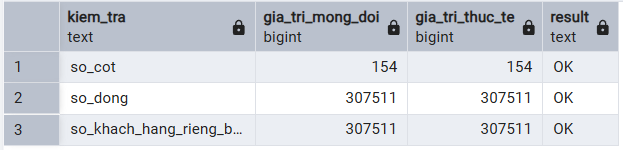

**Nhận xét:** Khi chạy lại pipeline, cả ba dòng cần trả về `OK`. Số dòng phải bằng đúng 307.511 của `application_train` nên `LEFT JOIN` không loại mất khách hàng nào; số khách hàng riêng biệt cũng phải bằng 307.511 nên không có khách nào bị nhân thành nhiều dòng. Số cột kỳ vọng là 154, gồm 122 cột gốc và 32 cột summary.


### 7.2. Kiểm tra TARGET sau join


Đoạn code bên dưới đối chiếu phân bố `TARGET` giữa bảng gốc và bảng phẳng.


In [ ]:
-- 10_check_flat_target.sql
-- Muc dich: doi chieu phan bo TARGET giua application_train va application_flat.
-- Hai dong ket qua phai giong het nhau. Neu join lam mat khach hang thi ty le lech ngay.
-- Giai thich chi tiet: xem Muc 7.2 trong notebook 02.

SELECT
    'application_train' AS bang,
    COUNT(*)::BIGINT AS tong_dong,
    SUM(CASE WHEN target = 1 THEN 1 ELSE 0 END)::BIGINT AS so_target_1,
    SUM(CASE WHEN target = 0 THEN 1 ELSE 0 END)::BIGINT AS so_target_0,
    ROUND(100.0 * SUM(CASE WHEN target = 1 THEN 1 ELSE 0 END) / COUNT(*), 3) AS ty_le_target_1
FROM application_train
UNION ALL
SELECT
    'application_flat',
    COUNT(*)::BIGINT,
    SUM(CASE WHEN target = 1 THEN 1 ELSE 0 END)::BIGINT,
    SUM(CASE WHEN target = 0 THEN 1 ELSE 0 END)::BIGINT,
    ROUND(100.0 * SUM(CASE WHEN target = 1 THEN 1 ELSE 0 END) / COUNT(*), 3)
FROM application_flat;

**Out put:**

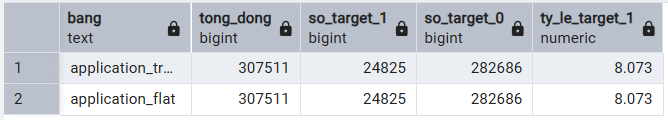

**Nhận xét:** Hai dòng kết quả giống hệt nhau về cả số dòng, số khách `TARGET = 1`, số khách `TARGET = 0` lẫn tỉ lệ. Nhãn cần dự đoán được giữ nguyên vẹn qua phép join, và tỉ lệ mất cân bằng của bài toán không bị thay đổi — nếu join lỡ làm mất một nhóm khách hàng nào đó thì tỉ lệ này đã lệch.


### 7.3. Kiểm tra dữ liệu thiếu sau join


Sau `LEFT JOIN`, khách hàng chưa từng vay ở đâu sẽ có các cột summary mang giá trị `NULL`. Đây là kết quả đúng chứ không phải lỗi, nhưng cần chứng minh bằng số liệu.

Đoạn code bên dưới đếm số dòng `NULL` của từng nhóm cột, rồi so với số kỳ vọng tính từ chính database theo công thức: **số khách của `application_train` trừ đi số khách có mặt trong bảng summary tương ứng**.


In [ ]:
-- 11_check_flat_nulls.sql
-- Muc dich: chung minh cac o NULL sau LEFT JOIN la dung, khong phai do join lam mat du lieu.
-- so_dong_null   : dem thang tren application_flat.
-- null_mong_doi  : tinh tu chinh database = so khach cua application_train
--                  tru di so khach co mat trong bang summary tuong ung.
-- Hai con so bang nhau nghia la LEFT JOIN khong danh roi khach hang nao.
-- Giai thich chi tiet: xem Muc 7.3 trong notebook 02.

SELECT
    nhom_cot,
    so_dong_null,
    null_mong_doi,
    CASE WHEN so_dong_null = null_mong_doi THEN 'OK' ELSE 'CAN_KIEM_TRA' END AS result
FROM (
    SELECT
        'bureau' AS nhom_cot,
        (SELECT COUNT(*) FROM application_flat WHERE bureau_count IS NULL)::BIGINT AS so_dong_null,
        ((SELECT COUNT(*) FROM application_train)
         - (SELECT COUNT(*) FROM bureau_summary s
            JOIN application_train a ON a.sk_id_curr = s.sk_id_curr))::BIGINT AS null_mong_doi
    UNION ALL
    SELECT
        'previous_application',
        (SELECT COUNT(*) FROM application_flat WHERE previous_count IS NULL)::BIGINT,
        ((SELECT COUNT(*) FROM application_train)
         - (SELECT COUNT(*) FROM previous_application_summary s
            JOIN application_train a ON a.sk_id_curr = s.sk_id_curr))::BIGINT
    UNION ALL
    SELECT
        'installments_payments',
        (SELECT COUNT(*) FROM application_flat WHERE installments_count IS NULL)::BIGINT,
        ((SELECT COUNT(*) FROM application_train)
         - (SELECT COUNT(*) FROM installments_payments_summary s
            JOIN application_train a ON a.sk_id_curr = s.sk_id_curr))::BIGINT
    UNION ALL
    SELECT
        'pos_cash_balance',
        (SELECT COUNT(*) FROM application_flat WHERE pos_cash_count IS NULL)::BIGINT,
        ((SELECT COUNT(*) FROM application_train)
         - (SELECT COUNT(*) FROM pos_cash_balance_summary s
            JOIN application_train a ON a.sk_id_curr = s.sk_id_curr))::BIGINT
    UNION ALL
    SELECT
        'credit_card_balance',
        (SELECT COUNT(*) FROM application_flat WHERE credit_card_count IS NULL)::BIGINT,
        ((SELECT COUNT(*) FROM application_train)
         - (SELECT COUNT(*) FROM credit_card_balance_summary s
            JOIN application_train a ON a.sk_id_curr = s.sk_id_curr))::BIGINT
) AS ket_qua
ORDER BY nhom_cot;

**Out put:**

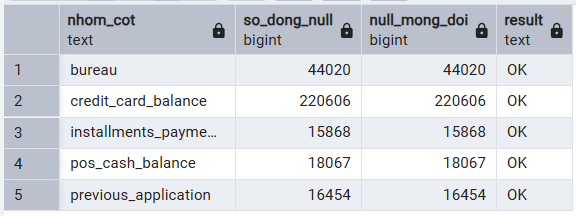

**Nhận xét:** Cả năm nhóm cột trả về `OK`, số dòng `NULL` khớp chính xác với số kỳ vọng, chứng tỏ `LEFT JOIN` không đánh rơi khách hàng nào.

| Nhóm cột | Số khách có dữ liệu | Số dòng `NULL` |
|---|---|---|
| `bureau` | 263.491 | 44.020 |
| `credit_card_balance` | 86.905 | 220.606 |
| `installments_payments` | 291.643 | 15.868 |
| `pos_cash_balance` | 289.444 | 18.067 |
| `previous_application` | 291.057 | 16.454 |

Đáng chú ý nhất là `credit_card_balance`: chỉ 86.905 trên 307.511 khách hàng từng có dữ liệu thẻ tín dụng, tức hơn 70% khách hàng để trống toàn bộ nhóm cột này. Đây là thông tin quan trọng cho Notebook 03, vì các cột đó không thể xử lý thiếu dữ liệu theo cách thông thường — bản thân việc khách không có thẻ tín dụng đã là một tín hiệu, không phải dữ liệu bị mất.


## 8. Kết nối PostgreSQL từ Python

### 8.1. Kết nối và kiểm tra bằng psycopg2


Thông tin kết nối được đọc từ file `.env` ở thư mục gốc dự án. File này chứa mật khẩu nên đã được gitignore, không đẩy lên GitHub. Máy nào chưa có thì sao chép `.env.example` thành `.env` rồi điền mật khẩu PostgreSQL của máy mình.

Đoạn code bên dưới tạo kết nối rồi kiểm tra bằng `SELECT version()` và `SELECT current_database()`.


In [1]:
from pathlib import Path
import os

import pandas as pd
import psycopg2
from dotenv import load_dotenv
from IPython.display import display

# Nếu chạy notebook từ thư mục notebooks/, quay về thư mục gốc dự án.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Thông tin kết nối đọc từ .env ở thư mục gốc, file này không được commit lên GitHub.
load_dotenv(PROJECT_ROOT / ".env")

conn = psycopg2.connect(
    host=os.getenv("DB_HOST", "localhost"),
    port=os.getenv("DB_PORT", "5432"),
    dbname=os.getenv("DB_NAME", "credit_risk_db"),
    user=os.getenv("DB_USER", "postgres"),
    password=os.getenv("DB_PASSWORD"),
)

with conn.cursor() as cur:
    cur.execute("SELECT version();")
    print("PostgreSQL:", cur.fetchone()[0].split(",")[0])
    cur.execute("SELECT current_database();")
    print("Database  :", cur.fetchone()[0])

PostgreSQL: PostgreSQL 18.4 on x86_64-windows
Database  : credit_risk_db


**Nhận xét:** Kết nối thành công, notebook đọc được phiên bản PostgreSQL và tên database đang dùng. Từ đây Python có thể truy vấn trực tiếp mà không cần mở pgAdmin.

Dự án dùng `psycopg2` trực tiếp, không qua SQLAlchemy. Khi truyền connection của `psycopg2` vào `pandas.read_sql`, pandas sẽ in một cảnh báo gợi ý dùng SQLAlchemy — đó chỉ là cảnh báo, truy vấn vẫn chạy đúng.


### 8.2. Bàn giao dữ liệu cho Notebook 03

Đoạn code bên dưới đọc `application_flat` từ PostgreSQL bằng `pandas.read_sql` để xác nhận Notebook 03 lấy được dữ liệu.


In [2]:
# Kich thuoc bang ban giao cho Notebook 03.
shape = pd.read_sql(
    """
    SELECT
        (SELECT COUNT(*) FROM application_flat) AS so_dong,
        (SELECT COUNT(*) FROM information_schema.columns
         WHERE table_schema = 'public' AND table_name = 'application_flat') AS so_cot
    """,
    conn,
)
print(shape.to_string(index=False))

# Xem thu vai dong dau, chi lay mot phan cot cho de nhin.
preview = pd.read_sql(
    """
    SELECT sk_id_curr, target, bureau_count, previous_count,
           installments_count, pos_cash_count, credit_card_count
    FROM application_flat
    ORDER BY sk_id_curr
    LIMIT 5
    """,
    conn,
)
display(preview)

conn.close()
print("Da dong ket noi.")

C:\Users\Hung Nguyen\AppData\Local\Temp\ipykernel_12668\875482340.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  shape = pd.read_sql(


 so_dong  so_cot
Cần chạy lại SQL 06–09 để cập nhật kích thước application_flat.


C:\Users\Hung Nguyen\AppData\Local\Temp\ipykernel_12668\875482340.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  preview = pd.read_sql(


,sk_id_curr,target,bureau_count,previous_count,installments_count,pos_cash_count,credit_card_count
0,100002,1,8.0,1,19,19,NaN
1,100003,0,4.0,3,25,28,NaN
2,100004,0,2.0,1,3,4,NaN
3,100006,0,NaN,9,16,21,6.0
4,100007,0,1.0,6,66,66,NaN


Da dong ket noi.


**Nhận xét:** Sau khi chạy lại pipeline, `application_flat` cần đọc được từ Python với 307.511 dòng và 154 cột. Các cột `bureau_count`, `previous_count`, `credit_card_count`... xuất hiện giá trị `NaN` ở những khách hàng không có lịch sử tương ứng, đúng như kết quả kiểm tra ở Mục 7.3.

Pipeline dữ liệu đã sẵn sàng bàn giao: từ Notebook 03 trở đi, toàn bộ notebook chỉ đọc dữ liệu từ PostgreSQL bằng `pandas.read_sql` thay vì quay lại đọc file CSV, giúp quy trình nhất quán và gần với cách triển khai trong doanh nghiệp.


## 9. Tổng kết

Notebook 02 đưa 8 file CSV vào PostgreSQL, tổng hợp các bảng phụ về mức khách hàng và ghép thành bảng `application_flat` thiết kế gồm 307.511 dòng × 154 cột, mỗi khách hàng đúng một dòng.

| Câu hỏi cốt lõi | Trả lời |
|---|---|
| Dữ liệu vào PostgreSQL đúng chưa? | Số dòng, số cột và kiểu dữ liệu đều khớp thiết kế (Mục 3) |
| Tích hợp nhiều bảng bằng cách nào? | Aggregate về `sk_id_curr` (Mục 5) rồi `LEFT JOIN` (Mục 6) |
| Dữ liệu nào dùng cho ML? | `application_flat`, giữ nguyên nhãn `TARGET` (Mục 7) |
| Sẵn sàng cho Notebook 03 chưa? | Python đọc được qua `psycopg2` (Mục 8) |

---


| Phát hiện từ NB02 | Notebook | Việc cần làm |
|---|---|---|
| 220.606 khách (71,7%) không có dữ liệu thẻ tín dụng | NB03 | Không điền median cho nhóm cột `credit_card_*` — đây là tín hiệu, không phải dữ liệu thiếu |
| Các cột summary có `NULL` do khách chưa từng vay | NB03 | Phân biệt "không có lịch sử" với "dữ liệu bị thiếu" |
| `TARGET` giữ nguyên tỉ lệ mất cân bằng | NB06 | Chọn metric phù hợp, không dùng accuracy |
| Đặc trưng `bureau_balance` đã được gom qua `bureau` | NB03 | Xử lý các giá trị `NULL` hợp lý sau join |
